# 5. Tabular Model Interpretation

This notebook interprets the strongest tabular baseline model developed so far, XGBoost. Since fraud detection models need to be both accurate and explainable, this notebook examines which anonymized transaction features contribute most to the model's predictions. The analysis includes built-in XGBoost feature importance, permutation importance, and a SHAP-based interpretation.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import joblib

from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    classification_report,
    average_precision_score,
    roc_auc_score
)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 1000)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Libraries imported successfully.")

Libraries imported successfully.


## 5.1 Load Saved Data and Model

The train, validation, and test splits created earlier are loaded together with the trained XGBoost model. The interpretation analysis is mainly performed on the test set so that the explanations reflect the final evaluation data.

In [2]:
PROJECT_DIR = Path.cwd().resolve()

if PROJECT_DIR.name == "notebooks":
    PROJECT_DIR = PROJECT_DIR.parent

split_dir = PROJECT_DIR / "data" / "processed" / "tabular_splits"
models_dir = PROJECT_DIR / "models"
results_dir = PROJECT_DIR / "results"
figures_dir = PROJECT_DIR / "figures"

figures_dir.mkdir(parents=True, exist_ok=True)
results_dir.mkdir(parents=True, exist_ok=True)

X_train = pd.read_csv(split_dir / "X_train.csv")
X_val = pd.read_csv(split_dir / "X_val.csv")
X_test = pd.read_csv(split_dir / "X_test.csv")

y_train = pd.read_csv(split_dir / "y_train.csv").squeeze("columns")
y_val = pd.read_csv(split_dir / "y_val.csv").squeeze("columns")
y_test = pd.read_csv(split_dir / "y_test.csv").squeeze("columns")

xgb_model = joblib.load(models_dir / "xgboost_model.pkl")

print("Data and model loaded successfully.")
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

Data and model loaded successfully.
X_train: (27938, 165)
X_val: (9313, 165)
X_test: (9313, 165)


In [3]:
xgb_test_pred = xgb_model.predict(X_test)
xgb_test_proba = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost Test Classification Report:")
print(classification_report(y_test, xgb_test_pred, digits=4))

print("ROC-AUC:", round(roc_auc_score(y_test, xgb_test_proba), 4))
print("PR-AUC:", round(average_precision_score(y_test, xgb_test_proba), 4))

XGBoost Test Classification Report:
              precision    recall  f1-score   support

           0     0.9936    0.9974    0.9955      8404
           1     0.9749    0.9406    0.9574       909

    accuracy                         0.9918      9313
   macro avg     0.9843    0.9690    0.9765      9313
weighted avg     0.9918    0.9918    0.9918      9313

ROC-AUC: 0.9974
PR-AUC: 0.986


The XGBoost model is reloaded and evaluated again to confirm that the saved model is working correctly. This also ensures that the interpretation analysis is based on the same trained model used in the baseline comparison.

## 5.2 Built-in XGBoost Feature Importance

XGBoost provides a built-in feature importance measure based on how frequently and effectively features are used in the ensemble. Since the Elliptic dataset uses anonymized numerical features, the analysis focuses on relative importance rather than semantic interpretation of individual variables.

In [4]:
feature_importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": xgb_model.feature_importances_
}).sort_values(by="importance", ascending=False)

display(feature_importance_df.head(20))

,feature,importance
89,91,0.097659
58,60,0.062988
64,66,0.052368
52,54,0.048798
4,6,0.045518
13,15,0.032535
45,47,0.028794
152,154,0.026788
162,164,0.025613
48,50,0.023274


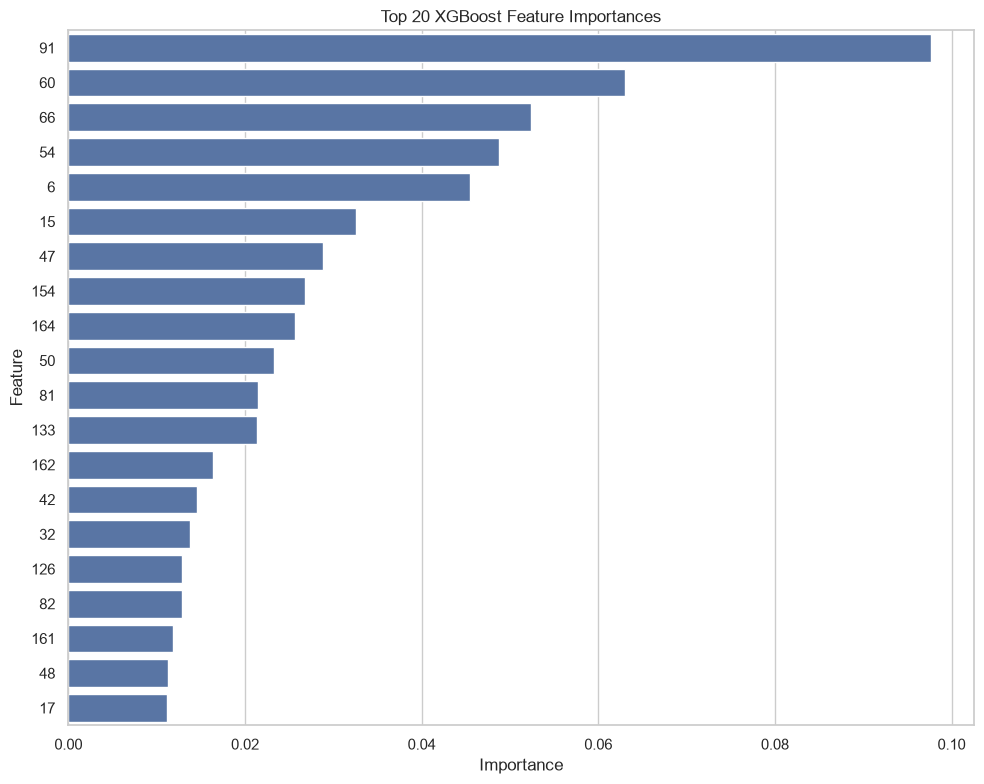

In [5]:
top_n = 20
top_features = feature_importance_df.head(top_n)

plt.figure(figsize=(10, 8))
sns.barplot(data=top_features, x="importance", y="feature")
plt.title("Top 20 XGBoost Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(figures_dir / "xgboost_top20_feature_importance.png", dpi=300)
plt.show()

The built-in feature importance ranking shows that the XGBoost model relies more strongly on a subset of transaction features rather than treating all variables equally. Although the features are anonymized, this is still useful because it shows that the model is learning structured patterns from the feature space.

## 5.3 Permutation Importance

Permutation importance provides another way to estimate feature influence. It measures how much model performance decreases when the values of a feature are randomly shuffled. A larger decrease suggests that the feature is more important for prediction.

In [6]:
# A sample for faster permutation importance
sample_size = min(3000, len(X_test))

X_test_sample = X_test.sample(n=sample_size, random_state=42)
y_test_sample = y_test.loc[X_test_sample.index]

print("Permutation importance sample size:", X_test_sample.shape)

Permutation importance sample size: (3000, 165)


In [7]:
perm_importance = permutation_importance(
    xgb_model,
    X_test_sample,
    y_test_sample,
    scoring="average_precision",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

perm_importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm_importance.importances_mean,
    "importance_std": perm_importance.importances_std
}).sort_values(by="importance_mean", ascending=False)

display(perm_importance_df.head(20))

,feature,importance_mean,importance_std
58,60,0.011360,0.002115
1,3,0.008457,0.001556
52,54,0.005092,0.001247
2,4,0.002263,0.000319
89,91,0.001948,0.000692
15,17,0.001886,0.000611
4,6,0.001655,0.000970
160,162,0.001285,0.000713
79,81,0.001245,0.000382
99,101,0.001221,0.000302


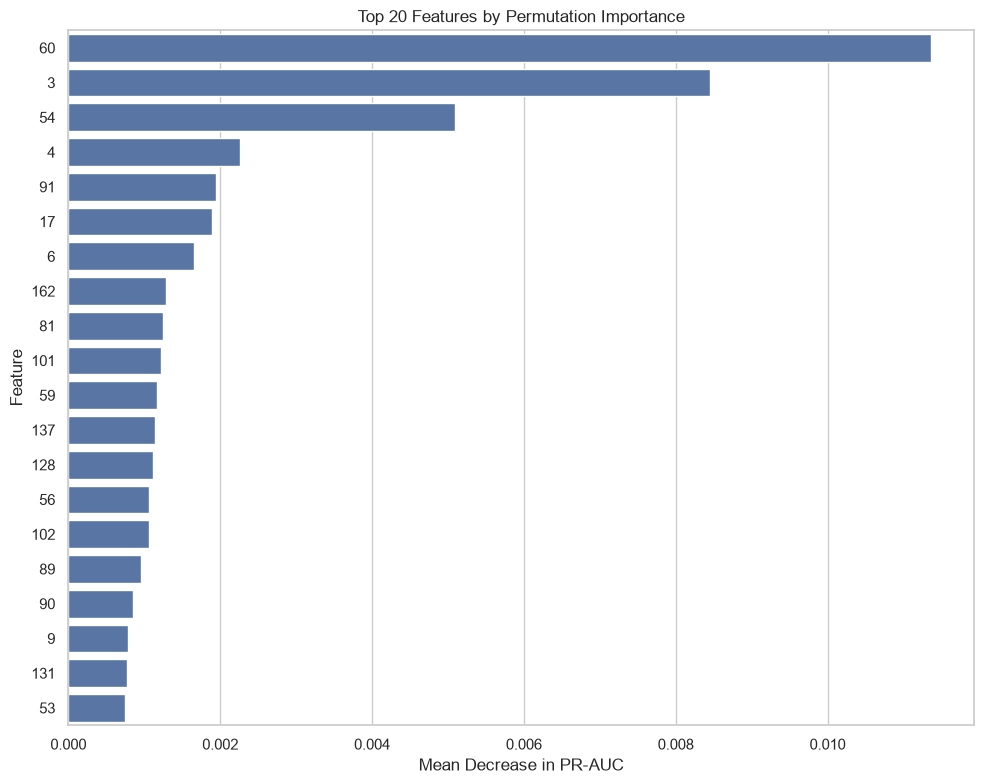

In [8]:
top_perm_features = perm_importance_df.head(20)

plt.figure(figsize=(10, 8))
sns.barplot(data=top_perm_features, x="importance_mean", y="feature")
plt.title("Top 20 Features by Permutation Importance")
plt.xlabel("Mean Decrease in PR-AUC")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(figures_dir / "xgboost_top20_permutation_importance.png", dpi=300)
plt.show()

Permutation importance complements the built-in XGBoost importance scores by measuring the impact of feature disruption on predictive performance. Features with higher permutation importance appear to contribute more strongly to illicit transaction detection.

## 5.4 Compare Built-in and Permutation Importance

The two importance methods are compared to see whether the same features appear consistently important. Consistency across methods provides stronger evidence that those features are influential in the model.

In [9]:
top_builtin_set = set(feature_importance_df.head(20)["feature"])
top_perm_set = set(perm_importance_df.head(20)["feature"])

common_top_features = sorted(list(top_builtin_set.intersection(top_perm_set)))

print("Number of overlapping top features:", len(common_top_features))
print("Common top features:")
print(common_top_features)

Number of overlapping top features: 7
Common top features:
['162', '17', '54', '6', '60', '81', '91']


In [10]:
feature_importance_df.to_csv(results_dir / "xgboost_builtin_feature_importance.csv", index=False)
perm_importance_df.to_csv(results_dir / "xgboost_permutation_importance.csv", index=False)

print("Interpretation result tables saved to:")
print(results_dir.relative_to(PROJECT_DIR))

Interpretation result tables saved to:
results


## 5.5 SHAP Interpretation

SHAP is used as a post-hoc explainability method to estimate how individual features contribute to model predictions. Since SHAP can be computationally expensive, the analysis is performed on a small sample of the test set.

In [11]:
try:
    import shap
    print("SHAP imported successfully.")
    shap_available = True
except Exception as e:
    print("SHAP import failed.")
    print("Error:", e)
    shap_available = False

SHAP imported successfully.


In [12]:
shap_sample_size = min(1000, len(X_test))

X_shap = X_test.sample(n=shap_sample_size, random_state=42)

print("SHAP sample shape:", X_shap.shape)

SHAP sample shape: (1000, 165)


In [13]:
if shap_available:
    explainer = shap.TreeExplainer(xgb_model)
    shap_values = explainer.shap_values(X_shap)

    print("SHAP values computed successfully.")
else:
    print("Skipping SHAP computation because SHAP is not available.")

SHAP values computed successfully.


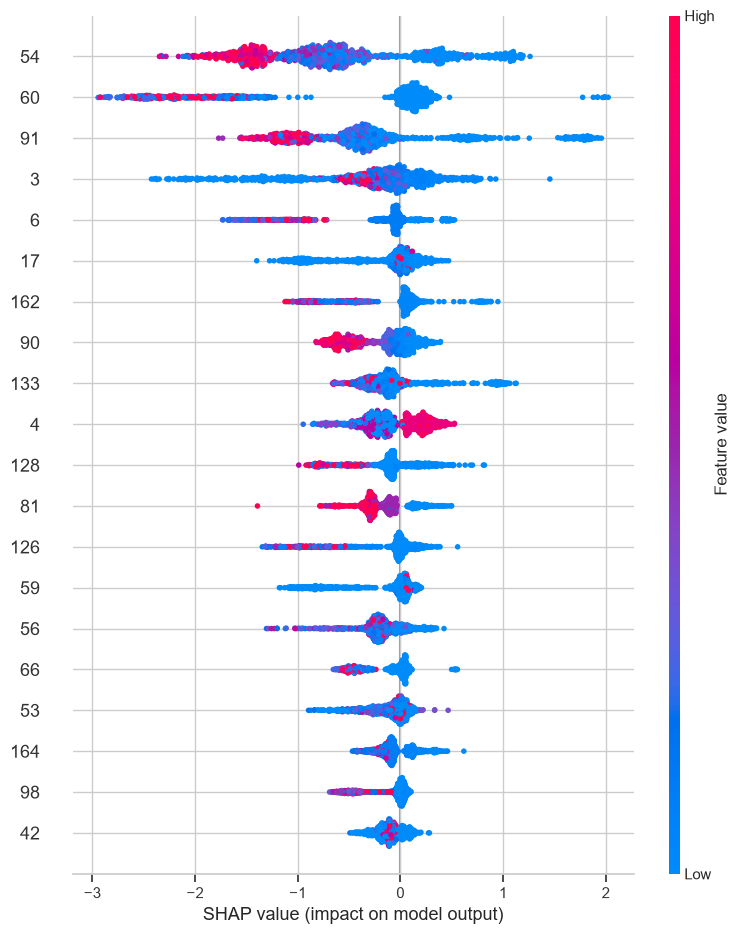

In [14]:
if shap_available:
    shap.summary_plot(shap_values, X_shap, show=False)
    plt.tight_layout()
    plt.savefig(figures_dir / "xgboost_shap_summary_plot.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("SHAP summary plot skipped.")

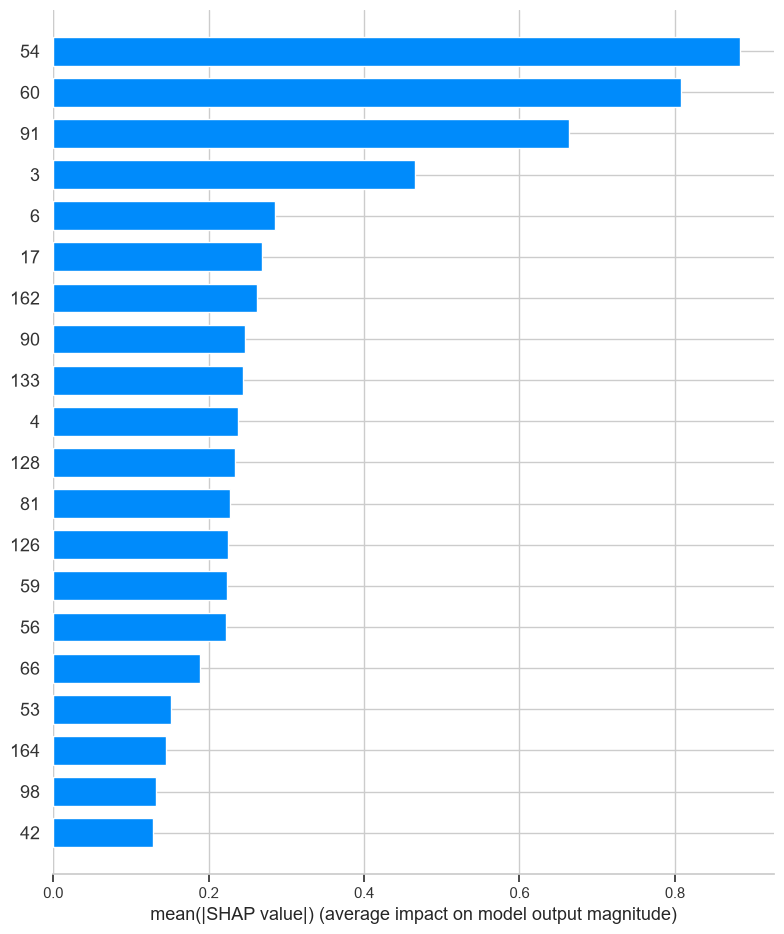

In [15]:
if shap_available:
    shap.summary_plot(shap_values, X_shap, plot_type="bar", show=False)
    plt.tight_layout()
    plt.savefig(figures_dir / "xgboost_shap_bar_plot.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("SHAP bar plot skipped.")

The SHAP plots provide a more detailed interpretation of model behavior by showing both global feature importance and the direction of feature contributions. Because the dataset features are anonymized, the focus is on identifying influential feature patterns rather than assigning domain-specific meanings to each feature.

In [16]:
if shap_available:
    if isinstance(shap_values, list):
        shap_array = shap_values[1]
    else:
        shap_array = shap_values

    shap_importance_df = pd.DataFrame({
        "feature": X_shap.columns,
        "mean_abs_shap_value": np.abs(shap_array).mean(axis=0)
    }).sort_values(by="mean_abs_shap_value", ascending=False)

    display(shap_importance_df.head(20))

    shap_output_path = (
        results_dir / "xgboost_shap_feature_importance.csv"
    )

    shap_importance_df.to_csv(
        shap_output_path,
        index=False
    )

    print("SHAP feature importance saved to:")
    print(shap_output_path.relative_to(PROJECT_DIR))
else:
    print("SHAP feature importance table skipped.")

,feature,mean_abs_shap_value
52,54,0.883353
58,60,0.808363
89,91,0.664026
1,3,0.465965
4,6,0.284802
15,17,0.268491
160,162,0.261793
88,90,0.246505
131,133,0.244258
2,4,0.237827


SHAP feature importance saved to:
results\xgboost_shap_feature_importance.csv


The SHAP-based feature importance table ranks features according to their average absolute contribution to model predictions. This provides a more detailed explanation than built-in feature importance because SHAP estimates how strongly each feature influences individual predictions before aggregating the results globally.

## 5.6 Interpretation Summary

This section summarizes the main findings from the tabular model interpretation stage.

In [17]:
summary_text = f"""
XGBoost was interpreted using built-in feature importance and permutation importance.
The top built-in feature was {feature_importance_df.iloc[0]['feature']}, while the top permutation-based feature was {perm_importance_df.iloc[0]['feature']}.
There were {len(common_top_features)} overlapping features among the top 20 features identified by both methods.
This suggests that the model relies on a subset of transaction features that consistently contribute to illicit transaction detection.
"""

print(summary_text)


XGBoost was interpreted using built-in feature importance and permutation importance.
The top built-in feature was 91, while the top permutation-based feature was 60.
There were 7 overlapping features among the top 20 features identified by both methods.
This suggests that the model relies on a subset of transaction features that consistently contribute to illicit transaction detection.



Overall, the interpretation analysis shows that XGBoost does not rely uniformly on all transaction features. Instead, several anonymized numerical features appear to contribute more strongly to illicit transaction detection.